# Big Data y Machine Learning (UBA) 2025
## Clase 2 - Parte III - Visualización de NaNs
En esta tutorial, simularemos datos con algunas variables muy parecidas a la Encuesta Permanente de Hogares (EPH). También, simularemos valores faltantes, como contabilizarlos y visualizarlos para una limpieza posterior de la base de datos. Este paso es muy util en el momento de **procesamiento y preparación** de la muestra analítica antes de correr cualquier modelo predictivo o método no supervisado.
Para dicha visualización de NaN usaremos el modulo de `seaborn`, también muy utilizada en procesamiento y visualización de datos en Python. Para más información ver [seaborn](https://seaborn.pydata.org/)

In [2]:
# Primero, installamos el paquete
!pip install seaborn

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Paso 1: Simulamos los datos

In [6]:
# Fijamos la semilla para obtener resultados reproducibles
np.random.seed(123)

In [8]:
# Creamos un arreglo de números enteros del 1 al 1000 para identificar a 1000 personas
personas = np.arange(1, 1000)

In [10]:
# Creamos un arreglo de años desde 2005 hasta 2025
anios = np.arange(2005, 2025)

In [12]:
# Creamos un DataFrame con todas las combinaciones posibles de personas y años
panel = pd.DataFrame([(persona, anio) for persona in personas for anio in anios], 
                     columns=['id_persona', 'anio'])

In [14]:
# Generamos edades aleatorias entre 18 y 64 años para cada observación
panel['edad'] = np.random.randint(18, 65, size=len(panel))

In [16]:
# Generamos alturas aleatorias con una distribución normal, media de 170cm y desviación estándar de 10cm
panel['altura'] = np.round(np.random.normal(170, 10, size=len(panel)), 1)

In [18]:
# Creamos una variable dummy para secundaria completa (0 o 1), con probabilidad del 70% para el valor 1
panel['secundaria_completa'] = np.random.choice([0, 1], size=len(panel), p=[0.3, 0.7])

In [20]:
# Generamos salarios aleatorios siguiendo una distribución normal con media de 60,000 y desviación estándar de 15,000
panel['salario'] = np.round(np.random.normal(60000, 15000, size=len(panel)), 2)

In [22]:
panel.shape

(19980, 6)

In [24]:
panel.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19980 entries, 0 to 19979
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_persona           19980 non-null  int64  
 1   anio                 19980 non-null  int64  
 2   edad                 19980 non-null  int64  
 3   altura               19980 non-null  float64
 4   secundaria_completa  19980 non-null  int64  
 5   salario              19980 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 936.7 KB


#### Simulamos los valores faltantes (NaN)

In [26]:
# Introducimos valores faltantes (NaN) en cada columna, según los porcentajes especificados
for col, prop in {'edad': 0.10, 'altura': 0.23, 'secundaria_completa': 0.05, 'salario': 0.30}.items():
    # Calculamos la cantidad de valores faltantes a introducir en la columna actual
    n_missing = int(np.floor(prop * len(panel)))
    # Seleccionamos índices aleatorios donde insertaremos los valores faltantes
    missing_indices = np.random.choice(panel.index, size=n_missing, replace=False)
    # Asignamos valores faltantes (NaN) a los índices seleccionados en la columna actual
    panel.loc[missing_indices, col] = np.nan

#### Base de datos "raw"

Ahora, recuerden lo que vimos en tutoriales para inspeccionar la base de datos

In [28]:
# Visualizamos los datos
panel.sample(10)

,id_persona,anio,edad,altura,secundaria_completa,salario
9624,482,2009,57.0,NaN,0.0,25531.98
17048,853,2013,64.0,161.6,0.0,35591.20
3313,166,2018,44.0,NaN,1.0,NaN
5226,262,2011,24.0,151.5,0.0,51611.21
8499,425,2024,24.0,165.2,1.0,63766.79
15282,765,2007,44.0,179.4,0.0,63310.84
13842,693,2007,49.0,178.8,0.0,48653.47
14971,749,2016,NaN,194.4,1.0,47936.89
14467,724,2012,36.0,169.3,NaN,NaN
14238,712,2023,NaN,170.9,1.0,59432.22


In [30]:
panel.info(verbose = True) #con esto, ya podemos ver la canrisas de valores no nulos por variable

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19980 entries, 0 to 19979
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_persona           19980 non-null  int64  
 1   anio                 19980 non-null  int64  
 2   edad                 17982 non-null  float64
 3   altura               15385 non-null  float64
 4   secundaria_completa  18981 non-null  float64
 5   salario              13986 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 936.7 KB


Veamos la estadistica descriptiva de la base de datos raw

In [32]:
panel.describe().round(2)

,id_persona,anio,edad,altura,secundaria_completa,salario
count,19980.00,19980.00,17982.00,15385.00,18981.00,13986.00
mean,500.00,2014.50,40.95,170.06,0.70,59829.24
std,288.39,5.77,13.55,9.98,0.46,14922.53
min,1.00,2005.00,18.00,134.80,0.00,2418.25
25%,250.00,2009.75,29.00,163.30,0.00,49823.77
50%,500.00,2014.50,41.00,170.00,1.00,59909.62
75%,750.00,2019.25,53.00,176.70,1.00,69949.54
max,999.00,2024.00,64.00,210.60,1.00,114657.07


### Paso 2: Contabilizamos y visualizamos los NaN

In [34]:
# Calcular el porcentaje de datos no nulos por año
percentage_data = panel.groupby('anio').apply(lambda x: x.notnull().mean() * 100)

/var/folders/s3/z1fnt3zs2nqd6lpnmt4yj7kh0000gn/T/ipykernel_4443/1108733437.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentage_data = panel.groupby('anio').apply(lambda x: x.notnull().mean() * 100)


In [36]:
# Eliminar las columnas innecesarias antes de graficar
percentage_data = percentage_data.drop(columns=['anio'])  # Eliminar 'anio' del DataFrame calculado

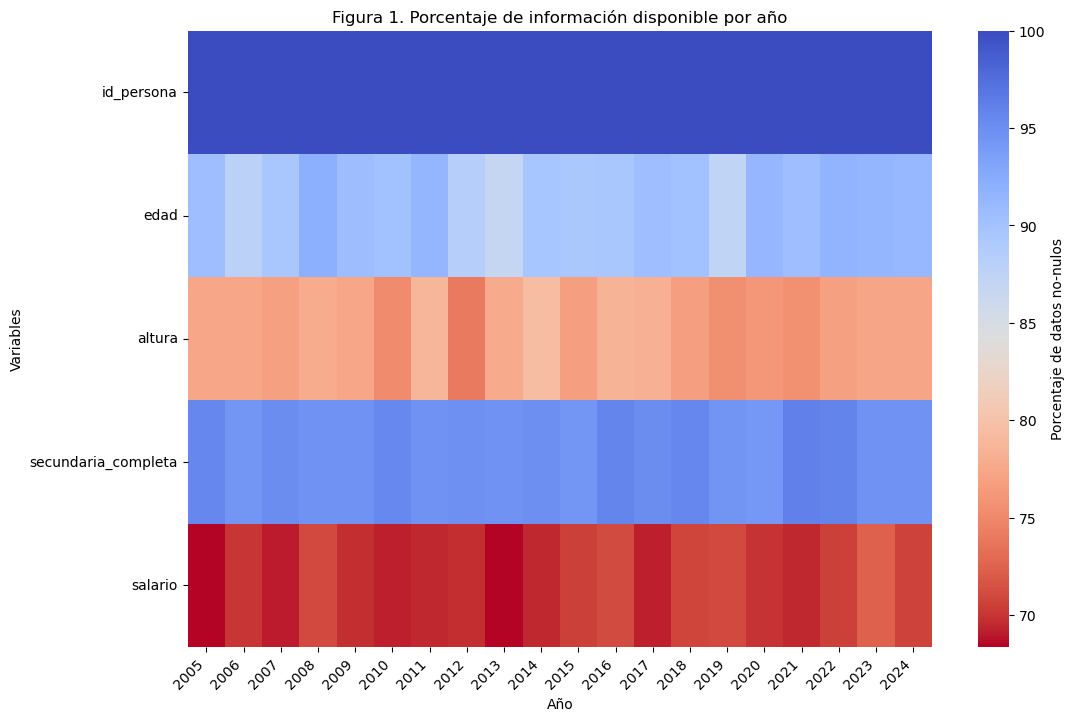

In [38]:
# Crear el heatmap sin etiquetas en las celdas
plt.figure(figsize=(12, 8))
sns.heatmap(percentage_data.T, annot=False, cmap="coolwarm_r",cbar_kws={'label': 'Porcentaje de datos no-nulos'})
plt.title("Figura 1. Porcentaje de información disponible por año")
plt.xlabel("Año")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Variables")
plt.yticks(rotation=0)
plt.show()